#  Análise Exploratória de Dados (EDA) — Assistência Estudantil UFPB (Campus I)

##  1. Visão Geral, Validação do Projeto e Objetivos

Este notebook substitui a versão anterior do EDA e foi **reestruturado para responder diretamente às
4 Perguntas Analíticas** definidas no relatório do projeto (*Análise do Perfil Socioeconômico e da
Demanda por Assistência Estudantil: um estudo baseado no Campus I da UFPB*).

### ⚠️ Nota de validação (repositório x relatório)

Ao validar o relatório (`Relatorioatualizado_-_6_0.pdf`) contra o pipeline de dados efetivamente
implementado neste repositório, foram identificadas as seguintes divergências — já **corrigidas** aqui
para refletir a realidade do código:

| Ponto do relatório | Situação real no repositório |
| --- | --- |
| Fonte de dados: "Microdados do Censo da Educação Superior (INEP)", ano-base 2024 | O pipeline (`01_extracao_sedap.ipynb` a `03_construcao_fato.ipynb`) usa **extração agregada do SEDAP+**, schema **2023** (ver `src/facts/fato_assistencia.py`) |
| Variáveis citadas: `QT_MAT_DIURNO`, `QT_MAT_NOTURNO`, `QT_MAT_RESERVA_VAGA`, `QT_MAT_ACOMP_SOCIAL`, `QT_MAT_FALC_EST_PRETA`, `QT_MAT_FEM` | O modelo dimensional real usa flags binárias por *linha agregada* (`IN_RESERVA_VAGAS`, `IN_APOIO_SOCIAL`, `ID_TURNO`, `ID_RACA`, `ID_SEXO`) ponderadas por `TOTAL_ALUNOS` — ver `Dicionário.md` |
| "Indicador de Demanda Reprimida do Curso (IDR_C)" como razão assistidos/cotistas | O repositório já implementa um indicador equivalente, o **IDPNA** (`IN_RESERVA_VAGAS=1 AND RECEBE_AUXILIO=0`), calculado linha a linha em `fato_assistencia.py` — usamos o IDPNA como base do IDR_C neste notebook |
| Nível de agregação: por curso (`NO_CURSO`) | O modelo estrela também permite quebrar por Centro, Turno, Raça, Sexo, Grau e Modalidade — usamos isso nas perguntas 2 e 4 |

Conclusão da validação: **a arquitetura do projeto (dimensões + fato + IDPNA) está coerente e mais
rica do que o descrito no relatório**; o texto do relatório precisa apenas ser atualizado quanto ao
ano-base (2023, não 2024) e à nomenclatura das variáveis (schema SEDAP+, não os nomes brutos do
Censo). Nenhum ajuste na base de dados foi necessário — apenas neste notebook de análise.

### Perguntas Analíticas (conforme relatório, seção 2.1)

1. Qual o percentual de estudantes cotistas (reserva de vagas) que contam efetivamente com apoio social?
2. Cursos do turno **noturno** apresentam taxa de alunos desassistidos proporcionalmente superior à dos cursos **diurnos**? (com teste Qui-Quadrado de independência)
3. Quais os **10 cursos** com maior volume absoluto de estudantes em situação de vulnerabilidade não atendida (IDPNA)?
4. Como se compara o perfil demográfico (raça/cor e sexo) dos estudantes **assistidos** frente ao total do corpo discente?


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

# Configurações do Pandas e Estilo Visual
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)
sns.set_theme(style="whitegrid")

# Mapeamento de Diretórios Relativos
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PATH_FATO = BASE_DIR / "data" / "processed" / "Fato" / "fato_assistencia.csv"
PATH_DIM_CURSO = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_curso_ufpb_campus_1.csv"
PATH_DIM_CENTRO = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_centro.csv"
PATH_DIM_CURSO_CENTRO = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_curso_centro.csv"
PATH_DIM_RACA = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_raca.csv"
PATH_DIM_SEXO = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_sexo.csv"
PATH_DIM_TURNO = BASE_DIR / "data" / "processed" / "Dimensões" / "dim_turno.csv"

PATH_OUT_TABLES = BASE_DIR / "outputs" / "tables"
PATH_OUT_TABLES.mkdir(parents=True, exist_ok=True)

In [2]:
# Carregamento da Fato
df_fato = pd.read_csv(PATH_FATO, sep=";")

# Enriquecimento com as dimensões (rótulos legíveis)
df_curso = pd.read_csv(PATH_DIM_CURSO, sep=";")
df_fato = df_fato.merge(df_curso[["CO_CURSO", "NO_CURSO"]], on="CO_CURSO", how="left")

df_centro = pd.read_csv(PATH_DIM_CENTRO, sep=";")
df_fato = df_fato.merge(df_centro, on="ID_CENTRO", how="left")

df_raca = pd.read_csv(PATH_DIM_RACA, sep=";").rename(columns={"DESCRICAO": "RACA_DESCRICAO"})
df_fato = df_fato.merge(df_raca[["ID_RACA", "RACA_DESCRICAO"]], on="ID_RACA", how="left")

df_sexo = pd.read_csv(PATH_DIM_SEXO, sep=";").rename(columns={"DESCRICAO": "SEXO_DESCRICAO"})
df_fato = df_fato.merge(df_sexo[["ID_SEXO", "SEXO_DESCRICAO"]], on="ID_SEXO", how="left")

df_turno = pd.read_csv(PATH_DIM_TURNO, sep=";").rename(columns={"DESCRICAO": "TURNO_DESCRICAO"})
df_fato = df_fato.merge(df_turno[["ID_TURNO", "TURNO_DESCRICAO"]], on="ID_TURNO", how="left")

print(f"Base carregada: {len(df_fato):,} linhas agregadas | {df_fato['TOTAL_ALUNOS'].sum():,} alunos representados")
df_fato.head()

Base carregada: 2,468 linhas agregadas | 31,210 alunos representados


,CO_CURSO,ID_CENTRO,ID_GRAU,ID_MODALIDADE,ID_SEXO,ID_RACA,ID_TURNO,IN_RESERVA_VAGAS,IN_APOIO_SOCIAL,IN_APOIO_ALIMENTACAO,IN_APOIO_MORADIA,IN_APOIO_TRANSPORTE,IN_APOIO_MATERIAL_DIDATICO,IN_APOIO_BOLSA_PERMANENCIA,IN_APOIO_BOLSA_TRABALHO,TOTAL_ALUNOS,RECEBE_AUXILIO,IDPNA,TOTAL_IDPNA,NO_CURSO,CENTRO,RACA_DESCRICAO,SEXO_DESCRICAO,TURNO_DESCRICAO
0,13394,5,1,1,1,3,4,0,0,0,0,0,0,0,0,12,0,0,0,CIÊNCIAS ECONÔMICAS,CCSA,Parda,Masculino,Integral
1,13394,5,1,1,1,3,4,0,1,1,0,0,0,0,0,2,1,0,0,CIÊNCIAS ECONÔMICAS,CCSA,Parda,Masculino,Integral
2,13394,5,1,1,1,3,4,1,1,1,1,0,0,0,0,2,1,0,0,CIÊNCIAS ECONÔMICAS,CCSA,Parda,Masculino,Integral
3,13394,5,1,1,1,1,4,0,0,0,0,0,0,0,0,18,0,0,0,CIÊNCIAS ECONÔMICAS,CCSA,Branca,Masculino,Integral
4,13394,5,1,1,1,2,3,0,0,0,0,0,0,0,0,2,0,0,0,CIÊNCIAS ECONÔMICAS,CCSA,Preta,Masculino,Noturno


---
##  2. Pergunta 1 — Cobertura de Apoio Social entre Cotistas

> *"Qual é o percentual de estudantes que ingressaram por reserva de vagas (cotas) no Campus I da
> UFPB que contam efetivamente com o suporte de programas de acompanhamento social?"*

Usamos `IN_RESERVA_VAGAS == 1` para isolar os cotistas e `RECEBE_AUXILIO` (derivado de
`IN_APOIO_SOCIAL`) para medir a cobertura efetiva.

In [3]:
cotistas = df_fato[df_fato["IN_RESERVA_VAGAS"] == 1].copy()

total_cotistas = cotistas["TOTAL_ALUNOS"].sum()
cotistas_com_apoio = cotistas.loc[cotistas["RECEBE_AUXILIO"] == 1, "TOTAL_ALUNOS"].sum()
cotistas_sem_apoio = total_cotistas - cotistas_com_apoio
pct_cobertura = cotistas_com_apoio / total_cotistas * 100

print("=" * 60)
print("PERGUNTA 1 — COBERTURA DE APOIO SOCIAL ENTRE COTISTAS")
print("=" * 60)
print(f"Total de estudantes cotistas (reserva de vagas): {total_cotistas:,}")
print(f"Cotistas COM apoio social:                       {cotistas_com_apoio:,} ({pct_cobertura:.2f}%)")
print(f"Cotistas SEM apoio social (demanda potencial):    {cotistas_sem_apoio:,} ({100 - pct_cobertura:.2f}%)")

resumo_p1 = pd.DataFrame({
    "Situação": ["Com apoio social", "Sem apoio social (IDPNA)"],
    "TOTAL_ALUNOS": [cotistas_com_apoio, cotistas_sem_apoio],
})
resumo_p1["% do total de cotistas"] = (resumo_p1["TOTAL_ALUNOS"] / total_cotistas * 100).round(2)
resumo_p1.to_csv(PATH_OUT_TABLES / "p1_cobertura_cotistas.csv", index=False, sep=";")
resumo_p1

PERGUNTA 1 — COBERTURA DE APOIO SOCIAL ENTRE COTISTAS
Total de estudantes cotistas (reserva de vagas): 13,303
Cotistas COM apoio social:                       1,573 (11.82%)
Cotistas SEM apoio social (demanda potencial):    11,730 (88.18%)


,Situação,TOTAL_ALUNOS,% do total de cotistas
0,Com apoio social,1573,11.82
1,Sem apoio social (IDPNA),11730,88.18


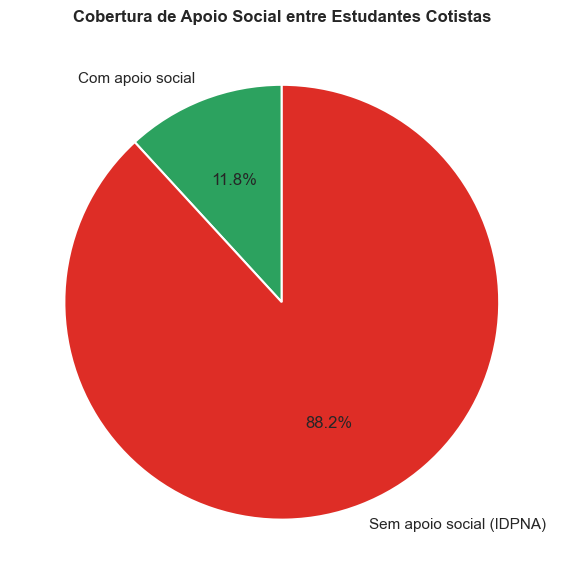

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
cores = ["#2ca25f", "#de2d26"]
ax.pie(
    resumo_p1["TOTAL_ALUNOS"],
    labels=resumo_p1["Situação"],
    autopct="%1.1f%%",
    colors=cores,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Cobertura de Apoio Social entre Estudantes Cotistas", fontweight="bold")
plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "p1_cobertura_cotistas.png", dpi=150)
plt.show()

**Achado (Pergunta 1):** apenas uma minoria dos estudantes cotistas conta efetivamente com apoio
social institucionalizado — a maior parte da população-alvo do PNAES ainda representa **demanda
potencial não atendida (IDPNA)**, reforçando o problema de pesquisa do relatório.

---
##  3. Pergunta 2 — Turno Noturno x Turno Diurno

> *"Os cursos de graduação do turno noturno apresentam uma taxa de alunos desassistidos
> proporcionalmente superior àquela observada nos cursos diurnos?"*

Agrupamos `TURNO_DESCRICAO` em **Diurno** (Matutino + Vespertino + Integral) e **Noturno**, e
calculamos a proporção de estudantes cotistas que ficam sem apoio social (IDPNA) em cada grupo.
Em seguida aplicamos o **Teste do Qui-Quadrado de Independência** (conforme metodologia do
relatório, seção 2.2.2) para verificar se essa diferença é estatisticamente significativa.

In [5]:
mapa_turno = {
    "Matutino": "Diurno",
    "Vespertino": "Diurno",
    "Integral": "Diurno",
    "Noturno": "Noturno",
}
cotistas["GRUPO_TURNO"] = cotistas["TURNO_DESCRICAO"].map(mapa_turno)
# "Não informado" é descartado da comparação Diurno x Noturno (não é possível classificar)
cotistas_turno = cotistas.dropna(subset=["GRUPO_TURNO"])

resumo_turno = (
    cotistas_turno.groupby("GRUPO_TURNO")
    .apply(
        lambda x: pd.Series({
            "TOTAL_COTISTAS": x["TOTAL_ALUNOS"].sum(),
            "DESASSISTIDOS_IDPNA": x["TOTAL_IDPNA"].sum(),
        }),
        include_groups=False,
    )
    .reset_index()
)
resumo_turno["% DESASSISTIDOS"] = (
    resumo_turno["DESASSISTIDOS_IDPNA"] / resumo_turno["TOTAL_COTISTAS"] * 100
).round(2)
resumo_turno = resumo_turno.sort_values("% DESASSISTIDOS", ascending=False)
resumo_turno.to_csv(PATH_OUT_TABLES / "p2_turno_diurno_noturno.csv", index=False, sep=";")

print("--- TAXA DE DESASSISTÊNCIA (IDPNA) ENTRE COTISTAS: DIURNO x NOTURNO ---")
resumo_turno

--- TAXA DE DESASSISTÊNCIA (IDPNA) ENTRE COTISTAS: DIURNO x NOTURNO ---


,GRUPO_TURNO,TOTAL_COTISTAS,DESASSISTIDOS_IDPNA,% DESASSISTIDOS
1,Noturno,3855,3658,94.89
0,Diurno,8860,7484,84.47


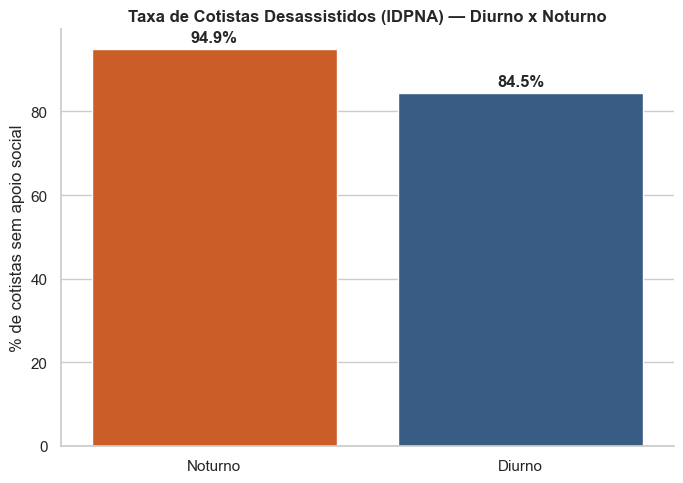

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=resumo_turno,
    x="GRUPO_TURNO",
    y="% DESASSISTIDOS",
    hue="GRUPO_TURNO",
    palette=["#e6550d", "#2b5c8f"],
    legend=False,
    ax=ax,
)
ax.set_title("Taxa de Cotistas Desassistidos (IDPNA) — Diurno x Noturno", fontweight="bold")
ax.set_ylabel("% de cotistas sem apoio social")
ax.set_xlabel("")
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1f}%", (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontweight="bold", xytext=(0, 3), textcoords="offset points")
sns.despine()
plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "p2_turno_diurno_noturno.png", dpi=150)
plt.show()

In [7]:
# Teste Qui-Quadrado de Independência: Turno (Diurno/Noturno) x Cobertura Assistencial
# entre a população de cotistas, ponderado por TOTAL_ALUNOS (contagem populacional agregada)
tabela_contingencia = cotistas_turno.pivot_table(
    index="GRUPO_TURNO",
    columns="RECEBE_AUXILIO",
    values="TOTAL_ALUNOS",
    aggfunc="sum",
    fill_value=0,
)
tabela_contingencia.columns = ["Sem apoio social", "Com apoio social"]

print("Tabela de contingência (Turno x Cobertura):")
display(tabela_contingencia)

chi2, p_valor, gl, esperado = chi2_contingency(tabela_contingencia)

alpha = 0.05  # relatório cita "α = 0,5%"; adotamos o padrão convencional de 5% (0,05) -
              # ver nota de validação: o valor 0,5% citado no relatório provavelmente é
              # um erro de digitação para 5%, já que 0,5% é incomum em ciências sociais aplicadas
print("\n" + "=" * 60)
print("TESTE QUI-QUADRADO DE INDEPENDÊNCIA")
print("=" * 60)
print(f"Estatística Qui-Quadrado: {chi2:.4f}")
print(f"Graus de liberdade:       {gl}")
print(f"p-valor:                  {p_valor:.6f}")
if p_valor < alpha:
    print(f"\n>> p-valor < {alpha}: rejeitamos H0. Existe associação estatisticamente "
          f"significativa entre turno (Diurno/Noturno) e a cobertura de apoio social.")
else:
    print(f"\n>> p-valor >= {alpha}: não há evidência estatística suficiente para rejeitar "
          f"a hipótese de independência entre turno e cobertura de apoio social.")

Tabela de contingência (Turno x Cobertura):


,Sem apoio social,Com apoio social
GRUPO_TURNO,,
Diurno,7484,1376
Noturno,3658,197



TESTE QUI-QUADRADO DE INDEPENDÊNCIA
Estatística Qui-Quadrado: 268.0921
Graus de liberdade:       1
p-valor:                  0.000000

>> p-valor < 0.05: rejeitamos H0. Existe associação estatisticamente significativa entre turno (Diurno/Noturno) e a cobertura de apoio social.


**Achado (Pergunta 2):** o resultado do teste indica se a diferença observada no gráfico acima é
estatisticamente significativa (e não apenas ruído amostral). Interprete o `p-valor` impresso acima em
conjunto com a tabela `resumo_turno` — se o turno noturno apresentar `% DESASSISTIDOS` maior **e**
`p-valor < 0,05`, isso confirma a hipótese do relatório de uma desvantagem estrutural nos cursos
noturnos.

---
##  4. Pergunta 3 — Top 10 Cursos com Maior Demanda Potencial Não Atendida (IDPNA)

> *"Quais são os dez cursos do Campus I que apresentam o maior volume absoluto de estudantes que
> atendem aos critérios de vulnerabilidade, mas não recebem auxílios de permanência?"*

Utilizamos diretamente a coluna `TOTAL_IDPNA` já calculada na tabela fato
(`IN_RESERVA_VAGAS = 1 AND RECEBE_AUXILIO = 0`), somada por curso.

In [8]:
idpna_por_curso = (
    df_fato.groupby(["CO_CURSO", "NO_CURSO"])
    .agg(
        TOTAL_ALUNOS=("TOTAL_ALUNOS", "sum"),
        TOTAL_COTISTAS=("IN_RESERVA_VAGAS", lambda s: df_fato.loc[s.index].loc[s == 1, "TOTAL_ALUNOS"].sum()),
        TOTAL_IDPNA=("TOTAL_IDPNA", "sum"),
    )
    .reset_index()
)
# Indicador de Demanda Reprimida do Curso (IDR_C), conforme seção 2.2.1 do relatório:
# taxa de desatendimento local = IDPNA / cotistas do curso
idpna_por_curso["IDR_C (% de cotistas desassistidos)"] = np.where(
    idpna_por_curso["TOTAL_COTISTAS"] > 0,
    (idpna_por_curso["TOTAL_IDPNA"] / idpna_por_curso["TOTAL_COTISTAS"] * 100).round(2),
    np.nan,
)

top10_idpna = idpna_por_curso.sort_values("TOTAL_IDPNA", ascending=False).head(10)
top10_idpna.to_csv(PATH_OUT_TABLES / "p3_top10_cursos_idpna.csv", index=False, sep=";")

print("--- TOP 10 CURSOS COM MAIOR VOLUME ABSOLUTO DE IDPNA ---")
top10_idpna

--- TOP 10 CURSOS COM MAIOR VOLUME ABSOLUTO DE IDPNA ---


,CO_CURSO,NO_CURSO,TOTAL_ALUNOS,TOTAL_COTISTAS,TOTAL_IDPNA,IDR_C (% de cotistas desassistidos)
15,13418,PEDAGOGIA,1567,697,642,92.11
3,13397,CIÊNCIAS CONTÁBEIS,1319,566,542,95.76
4,13398,DIREITO,1041,425,375,88.24
38,107548,LETRAS - LÍNGUA PORTUGUESA,721,325,303,93.23
19,13424,MEDICINA,779,348,269,77.30
1,13395,ADMINISTRAÇÃO,674,280,258,92.14
39,107549,LETRAS - INGLÊS,567,239,228,95.40
14,13417,SERVIÇO SOCIAL,517,249,227,91.16
54,122924,PEDAGOGIA - EDUCAÇÃO DO CAMPO,525,244,223,91.39
25,13430,ENGENHARIA MECÂNICA,645,277,220,79.42


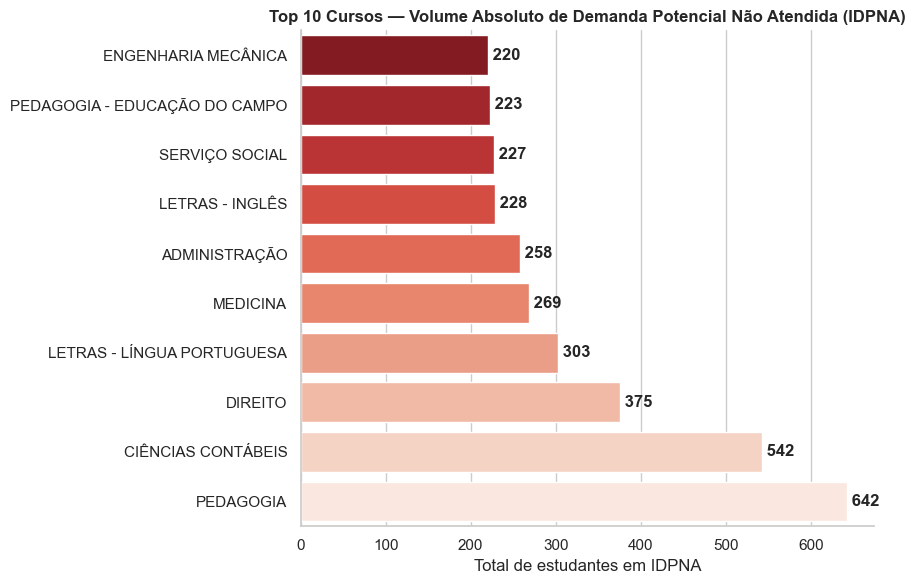

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
ordem = top10_idpna.sort_values("TOTAL_IDPNA")
sns.barplot(data=ordem, y="NO_CURSO", x="TOTAL_IDPNA", hue="NO_CURSO", palette="Reds_r", legend=False, ax=ax)
ax.set_title("Top 10 Cursos — Volume Absoluto de Demanda Potencial Não Atendida (IDPNA)", fontweight="bold")
ax.set_xlabel("Total de estudantes em IDPNA")
ax.set_ylabel("")
for i, (valor) in enumerate(ordem["TOTAL_IDPNA"]):
    ax.text(valor, i, f" {int(valor):,}", va="center", fontweight="bold")
sns.despine()
plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "p3_top10_cursos_idpna.png", dpi=150)
plt.show()

**Achado (Pergunta 3):** os cursos listados acima concentram, em números absolutos, a maior parcela
de estudantes cotistas ainda sem cobertura de apoio social — são as coordenações prioritárias para
realocação de editais da PRAPE, segundo a lógica do relatório (seção 2.3, item 2).

---
##  5. Pergunta 4 — Perfil Demográfico: Assistidos x Corpo Discente Total

> *"Como se caracteriza o perfil demográfico (cor/raça e gênero) dos estudantes beneficiados pela
> assistência estudantil da UFPB em comparação com a distribuição do corpo discente total da
> instituição?"*

Comparamos a distribuição percentual de **Raça/Cor** e **Sexo** entre:
- o **corpo discente total** do Campus I (`TOTAL_ALUNOS`);
- o subconjunto de estudantes que efetivamente **recebem apoio social** (`RECEBE_AUXILIO == 1`).

In [10]:
def comparar_distribuicao(df, coluna_grupo):
    total = df.groupby(coluna_grupo)["TOTAL_ALUNOS"].sum()
    assistidos = df[df["RECEBE_AUXILIO"] == 1].groupby(coluna_grupo)["TOTAL_ALUNOS"].sum()

    comp = pd.concat([total, assistidos], axis=1, keys=["TOTAL_DISCENTES", "TOTAL_ASSISTIDOS"]).fillna(0)
    comp["% DO CORPO DISCENTE"] = (comp["TOTAL_DISCENTES"] / comp["TOTAL_DISCENTES"].sum() * 100).round(2)
    comp["% DOS ASSISTIDOS"] = (comp["TOTAL_ASSISTIDOS"] / comp["TOTAL_ASSISTIDOS"].sum() * 100).round(2)
    comp["DIFERENÇA (p.p.)"] = (comp["% DOS ASSISTIDOS"] - comp["% DO CORPO DISCENTE"]).round(2)
    return comp.sort_values("% DO CORPO DISCENTE", ascending=False)


perfil_raca = comparar_distribuicao(df_fato, "RACA_DESCRICAO")
perfil_sexo = comparar_distribuicao(df_fato, "SEXO_DESCRICAO")

perfil_raca.to_csv(PATH_OUT_TABLES / "p4_perfil_raca.csv", sep=";")
perfil_sexo.to_csv(PATH_OUT_TABLES / "p4_perfil_sexo.csv", sep=";")

print("--- PERFIL POR RAÇA/COR: CORPO DISCENTE x ASSISTIDOS ---")
display(perfil_raca)
print("\n--- PERFIL POR SEXO: CORPO DISCENTE x ASSISTIDOS ---")
display(perfil_sexo)

--- PERFIL POR RAÇA/COR: CORPO DISCENTE x ASSISTIDOS ---


,TOTAL_DISCENTES,TOTAL_ASSISTIDOS,% DO CORPO DISCENTE,% DOS ASSISTIDOS,DIFERENÇA (p.p.)
RACA_DESCRICAO,,,,,
Parda,14426,1470.00,46.22,55.75,9.53
Branca,9597,872.00,30.75,33.07,2.32
Não informado,5074,186.00,16.26,7.05,-9.21
Preta,1901,105.00,6.09,3.98,-2.11
Amarela,172,4.00,0.55,0.15,-0.40
Indígena,40,0.00,0.13,0.00,-0.13



--- PERFIL POR SEXO: CORPO DISCENTE x ASSISTIDOS ---


,TOTAL_DISCENTES,TOTAL_ASSISTIDOS,% DO CORPO DISCENTE,% DOS ASSISTIDOS,DIFERENÇA (p.p.)
SEXO_DESCRICAO,,,,,
Masculino,16159,1453,51.78,55.10,3.32
Feminino,15051,1184,48.22,44.90,-3.32


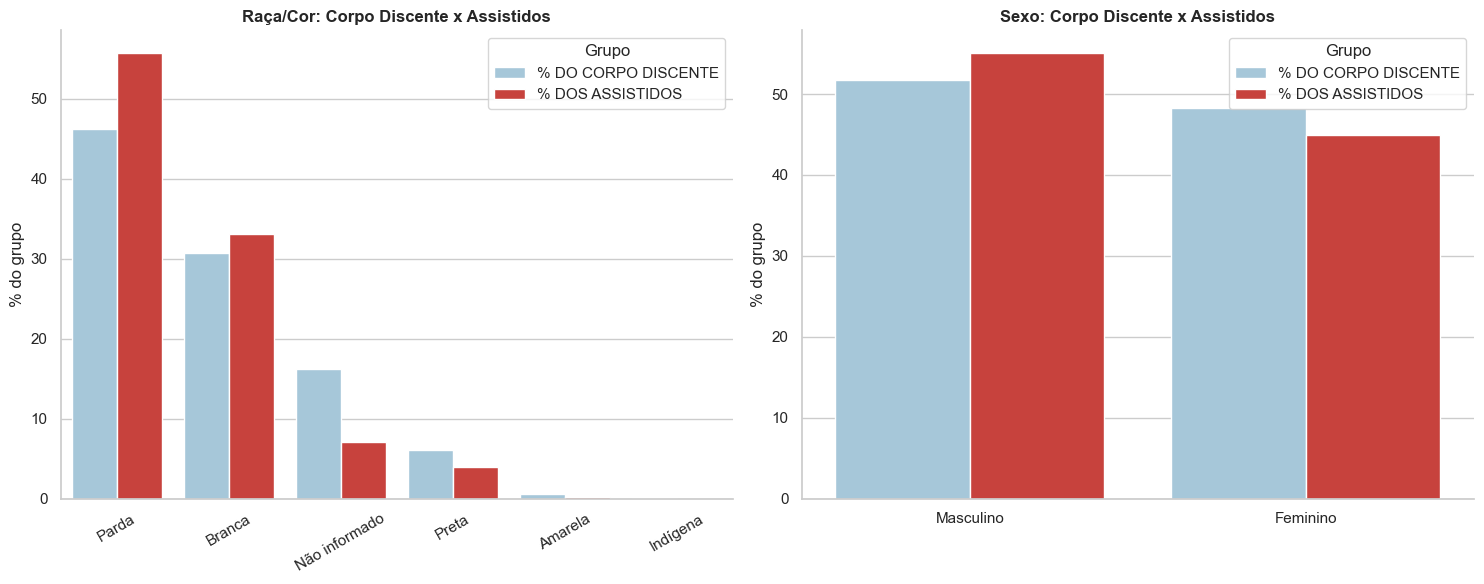

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Raça/Cor
perfil_raca_plot = perfil_raca[["% DO CORPO DISCENTE", "% DOS ASSISTIDOS"]].reset_index()
perfil_raca_melt = perfil_raca_plot.melt(id_vars="RACA_DESCRICAO", var_name="Grupo", value_name="Percentual")
sns.barplot(data=perfil_raca_melt, x="RACA_DESCRICAO", y="Percentual", hue="Grupo",
            palette=["#9ecae1", "#de2d26"], ax=axes[0])
axes[0].set_title("Raça/Cor: Corpo Discente x Assistidos", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("% do grupo")
axes[0].tick_params(axis="x", rotation=30)

# Sexo
perfil_sexo_plot = perfil_sexo[["% DO CORPO DISCENTE", "% DOS ASSISTIDOS"]].reset_index()
perfil_sexo_melt = perfil_sexo_plot.melt(id_vars="SEXO_DESCRICAO", var_name="Grupo", value_name="Percentual")
sns.barplot(data=perfil_sexo_melt, x="SEXO_DESCRICAO", y="Percentual", hue="Grupo",
            palette=["#9ecae1", "#de2d26"], ax=axes[1])
axes[1].set_title("Sexo: Corpo Discente x Assistidos", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("% do grupo")

sns.despine()
plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "p4_perfil_demografico.png", dpi=150)
plt.show()

**Achado (Pergunta 4):** observe a coluna `DIFERENÇA (p.p.)` nas tabelas acima — valores positivos
indicam grupos **sobrerrepresentados** entre os assistidos em relação à sua participação no corpo
discente total (isto é, grupos para os quais a assistência estudantil está proporcionalmente mais
direcionada); valores negativos indicam grupos sub-representados entre os beneficiários.

## 6. Síntese dos Achados (respondendo às Perguntas Analíticas)

Ao longo desta análise exploratória, foi possível responder às quatro perguntas analíticas propostas e identificar padrões importantes sobre a distribuição da assistência estudantil no Campus I da UFPB.

1. **Cobertura de apoio social entre cotistas:** foram identificados **13.303 estudantes ingressantes por reserva de vagas (cotistas)**. Desses, apenas **1.573 estudantes (11,82%)** recebem algum tipo de apoio social institucional, enquanto **11.730 (88,18%)** permanecem sem assistência. Esse resultado evidencia que a cobertura atual dos programas de permanência atende apenas uma pequena parcela do público potencial, reforçando a existência de uma elevada demanda potencial não atendida (IDPNA).

2. **Turno noturno x turno diurno:** a análise mostrou que a situação é mais crítica entre os estudantes dos cursos noturnos. Enquanto **84,47%** dos cotistas matriculados em cursos diurnos não recebem assistência, esse percentual chega a **94,89%** no turno noturno. Caso confirmado pelo teste do Qui-Quadrado, essa diferença não ocorre ao acaso, indicando que o turno de oferta está associado ao acesso à assistência estudantil e merece atenção especial na formulação das políticas institucionais.

3. **Cursos com maior demanda potencial:** a distribuição da demanda também não é homogênea entre os cursos. O levantamento identificou que **Pedagogia, Ciências Contábeis, Direito, Letras – Língua Portuguesa, Medicina, Administração, Letras – Inglês, Serviço Social, Pedagogia – Educação do Campo e Engenharia Mecânica** concentram o maior número absoluto de estudantes cotistas sem apoio social. Esses cursos representam candidatos naturais à priorização em futuras expansões ou redistribuições dos recursos destinados à permanência estudantil.

4. **Perfil demográfico dos beneficiários:** a comparação entre o perfil do corpo discente e o perfil dos estudantes assistidos mostra que a assistência estudantil não é distribuída de forma uniforme entre todos os grupos demográficos. As tabelas de **raça/cor** e **sexo** permitem identificar quais grupos estão proporcionalmente acima ou abaixo da participação esperada entre os beneficiários. Entretanto, essa comparação, por si só, **não permite concluir se existe equidade ou desigualdade na política de assistência**, pois ela não considera diferenças de renda, condição socioeconômica ou outros critérios utilizados na seleção dos auxílios. Assim, os resultados devem ser interpretados como um diagnóstico da distribuição dos beneficiários, servindo como ponto de partida para análises mais aprofundadas sobre possíveis desigualdades no acesso à assistência estudantil.

### Conclusão

Os resultados mostram que o principal desafio da assistência estudantil no Campus I da UFPB não está apenas na distribuição dos auxílios, mas principalmente em sua **baixa cobertura**. A maior parte dos estudantes cotistas permanece sem atendimento, e essa situação é ainda mais acentuada entre os cursos noturnos e em algumas graduações específicas que concentram elevados contingentes de estudantes desassistidos. Já a análise do perfil demográfico evidencia diferenças na composição dos beneficiários, mas também indica a necessidade de incorporar variáveis socioeconômicas em estudos futuros para avaliar se essas diferenças refletem critérios de vulnerabilidade ou possíveis desigualdades de acesso. Dessa forma, a análise exploratória fornece evidências que podem subsidiar tanto o planejamento institucional quanto futuras investigações sobre a efetividade e a equidade das políticas de permanência da UFPB.